<a href="https://colab.research.google.com/github/mbenedicto99/SaturnProject/blob/main/colab_treinamento_fase2_saturno_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2 — Treinamento comparativo de modelos e melhoria de resolução para 1024px
### Versão 4 — Projeto IA Saturno

Esta versão do notebook parte da anterior, já com o treinamento estabilizado (learning rate menor, scheduler, recorte de gradiente, parada antecipada, DataLoader sem multiprocessamento), e acrescenta quatro mudanças pedidas depois da segunda execução: uma etapa de validação de conteúdo bem mais rigorosa antes de qualquer imagem entrar no treino ou na super-resolução, o treinamento comparativo de quatro arquiteturas (CNN baseline, autoencoder convolucional, DnCNN e U-Net pequena) na mesma tabela de métricas, uma quebra da avaliação por faixa de severidade de degradação, e um conjunto de mapas de explicabilidade (diferença, resíduo amplificado e perfil radial).

A validação de conteúdo merece destaque à parte. A classificação zero-shot da Fase 1 confirmava se uma imagem mostrava "Saturno" de forma genérica, o que deixava passar registros em que o planeta aparece sem os anéis visíveis, ou apenas um recorte parcial do disco — conteúdo que não serve ao objetivo do projeto de separar visualmente disco e anéis. Esta versão troca esse critério por um bem mais estrito: a imagem só é aprovada se o classificador identificar o disco e os anéis simultaneamente, com confiança alta e uma margem clara sobre a segunda opção mais provável. Qualquer imagem reprovada fica de fora do treinamento e da etapa de super-resolução, com o motivo da reprovação registrado para auditoria.

### Mudanças desta versão (v4)

A execução completa da v3 mostrou o filtro de validação rigorosa aprovando só 20 das 500 imagens do catálogo (4%), o que deixou apenas 58 dos 1200 pares sintéticos e, depois do split, só 25 pares de treino -- pequeno demais para quatro arquiteturas de tamanhos bem diferentes, e a causa provável de o CNN baseline (~40 mil parâmetros) ter superado DnCNN e U-Net (centenas de milhares de parâmetros) na comparação. Esta versão traz cinco ajustes: a validação de conteúdo (seção 3.1) passa a reaproveitar o manifesto já recalibrado e classificado em três categorias da Fase 1, em vez de reclassificar do zero com um critério binário próprio; o carregamento dos pares sintéticos (seção 4) ganha aumento de dados (espelhamento horizontal e rotação pequena) no split de treino; o laço de treinamento (seção 7) ganha checkpoints de retomada entre desconexões do Colab e precisão mista (AMP); a avaliação (seção 8) passa a calcular LPIPS como métrica perceptual complementar ao lado de MSE/PSNR/SSIM; e a quebra por severidade (seção 8.1) troca `pd.qcut` direto por uma função defensiva (`qcut_safe`) que não quebra quando o conjunto de teste tem poucos valores distintos de erro de entrada.

## 1. Instalação de dependências

O Colab já traz `torch`, `torchvision`, `pandas`, `pillow`, `tqdm` e `matplotlib` pré-instalados e ligados à GPU disponível no ambiente; por isso esta célula não reinstala essas bibliotecas, para não substituir a versão de `torch` já compilada para a GPU por uma versão genérica de CPU. O que falta é instalado explicitamente: `transformers` (para carregar o Swin2SR e o CLIP do Hugging Face), `pytorch-msssim` (SSIM diferenciável, usado na função de perda do treinamento) e `scikit-image` (métricas de avaliação MSE/PSNR/SSIM sobre o conjunto de teste).

Antes de rodar o restante do notebook, confirme em Ambiente de execução > Alterar tipo de ambiente de execução que uma GPU está selecionada — o treinamento das quatro arquiteturas e, principalmente, a super-resolução em lote ficam ordens de grandeza mais lentos em CPU.

In [1]:
!pip -q install transformers pytorch-msssim scikit-image lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.9 MB/s eta 0:00:00


## 2. Imports e configuração da Fase 2

Os parâmetros abaixo controlam a validação de conteúdo, o treinamento das quatro arquiteturas e a etapa de super-resolução. `RANDOM_SEED` é o mesmo usado na Fase 1. `TARGET_UPSCALE_SIZE = 1024` e `SR_MODEL_NAME` definem a meta de resolução e o modelo do Hugging Face usado para chegar lá — o fator 4 do Swin2SR casa exatamente com `IMAGE_SIZE = 256` (256 × 4 = 1024).

A seção de validação de conteúdo usa o mesmo CLIP da Fase 1 (`CLIP_MODEL_NAME`), mas com um rótulo positivo que exige disco e anéis visíveis ao mesmo tempo, uma lista maior de rótulos negativos cobrindo os casos que apareceram nas execuções anteriores (Saturno sem anéis visíveis, recorte só do disco, ícones, gráficos, objetos sem relação), um limiar de confiança mais alto (`STRICT_CONFIDENCE_THRESHOLD`) e uma margem mínima sobre a segunda opção mais provável (`STRICT_MARGIN_THRESHOLD`), para reduzir casos de fronteira em que o classificador está pouco seguro.

In [2]:
import os
import json
import math
import random
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {DEVICE}")
if DEVICE.type == "cpu":
    print("Nenhuma GPU detectada. O notebook roda em CPU, mas o treinamento e a super-resolução ficam bem mais lentos.")

# Nome do dataset criado na Fase 1 (precisa bater com DATASET_NAME de lá).
DATASET_NAME = "dataset_saturno_v1"

# Tamanho em que os pares sintéticos da Fase 1 foram gerados.
IMAGE_SIZE = 256

# Meta de resolução final e modelo de super-resolução do Hugging Face.
# O fator x4 do Swin2SR casa exatamente com IMAGE_SIZE (256 x 4 = 1024).
TARGET_UPSCALE_SIZE = 1024
SR_MODEL_NAME = "caidas/swin2SR-classical-sr-x4-64"

# Validação rigorosa de conteúdo. A partir desta versão, a Fase 2
# prioriza reaproveitar o manifesto já classificado na Fase 1
# (approved_for_training.csv, seção 13.2 do notebook de dataset) em vez
# de rodar sua própria classificação do zero. Isso evita duas execuções
# de CLIP divergentes decidindo coisas diferentes sobre a mesma imagem,
# e evita gastar tempo de GPU reclassificando o que a Fase 1 já resolveu.
# A classificação própria abaixo (STRICT_SATURN_LABEL etc.) continua
# existindo como alternativa, usada apenas se aquele arquivo não for
# encontrado -- por exemplo, ao rodar esta Fase 2 contra uma Fase 1 mais
# antiga que ainda não gera esse manifesto.
#
# Quando a classificação própria roda, os rótulos e limiares agora
# espelham os da Fase 1 recalibrada (ver notebook de dataset, seção 2):
# um rótulo positivo, uma exceção para anéis quase de perfil, e um
# terceiro resultado (fila de revisão) em vez de só aprovado/reprovado.
# A execução anterior, com limiar de confiança 0.65 e margem 0.15,
# aprovou 20 das 500 imagens (4%), o que sobrou em só 58 dos 1200 pares
# sintéticos e 25 pares de treino -- pequeno demais para as quatro
# arquiteturas testadas, e a causa provável de o CNN baseline (menos
# parâmetros) ter superado DnCNN e U-Net (mais parâmetros) na
# comparação: com tão poucos exemplos, os modelos maiores tendem a
# decorar em vez de generalizar.
# Nesta versão, a Fase 1 passou a oferecer um segundo manifesto,
# approved_for_training_final.csv (seção 13.4 do notebook de dataset),
# que já incorpora a revisão manual da fila borderline feita na seção
# 13.3. Esse arquivo tem uma coluna final_status (confirmed,
# confirmed_by_manual_review ou rejected) em vez de status, e é a fonte
# preferida sempre que existir -- sem ele, toda a fila borderline seria
# aprovada em bloco, sem refletir nenhuma decisão individual da revisão
# manual. approved_for_training.csv (sem a revisão manual aplicada)
# continua servindo de segunda opção, para compatibilidade com uma Fase
# 1 que ainda não gerou o manifesto final.
USE_PHASE1_APPROVAL_MANIFEST = True
PHASE1_APPROVED_STATUSES = ["confirmed", "borderline"]
FINAL_MANIFEST_APPROVED_STATUSES = ["confirmed", "confirmed_by_manual_review"]

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
STRICT_SATURN_LABEL = "a clear photo of the planet Saturn showing both its disk and its rings"
STRICT_EDGE_ON_RINGS_LABEL = "a photo of the planet Saturn with its rings seen nearly edge-on, appearing as a thin line across the disk"
STRICT_NEGATIVE_LABELS = [
    "a photo of Saturn where the rings are not visible or too faint to see",
    "a close-up crop showing only part of a planet's disk with no rings visible",
    "a logo, icon, or website interface graphic",
    "a chart, graph, table, or diagram",
    "a photograph of a different planet or celestial object without rings",
    "a photograph unrelated to Saturn or astronomy",
]
STRICT_CONFIDENCE_THRESHOLD = 0.45
STRICT_MARGIN_THRESHOLD = 0.08
STRICT_BORDERLINE_CONFIDENCE_THRESHOLD = 0.35

# Aumento de dados nos pares sintéticos (novo nesta versão), para
# amenizar o efeito de um dataset efetivo pequeno após o filtro de
# conteúdo: espelhamento horizontal e pequenas rotações aplicados de
# forma idêntica à imagem degradada e à imagem alvo. Saturno não tem uma
# orientação fixa "correta" numa foto amadora, então isso não inventa
# estrutura nenhuma -- só multiplica os ângulos de vista já existentes.
AUGMENT_TRAIN_PAIRS = True
AUGMENT_MAX_ROTATION_DEGREES = 8

# Precisão mista (AMP) e ajustes de desempenho para treino em GPU.
USE_AMP = True
DATALOADER_PIN_MEMORY = True

# LPIPS (perceptual, backbone AlexNet) como métrica adicional de
# avaliação. MSE, PSNR e SSIM continuam sendo o critério primário de
# seleção do melhor modelo (ordenação por SSIM médio, seção 8); o LPIPS
# entra como leitura complementar, mais próxima da percepção visual
# humana, para a discussão qualitativa dos resultados.
LPIPS_NET = "alex"

# Hiperparâmetros de treinamento, compartilhados pelas quatro arquiteturas.
BATCH_SIZE = 16
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
VAL_EVERY_N_EPOCHS = 1
EARLY_STOPPING_PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 4
GRAD_CLIP_MAX_NORM = 1.0

# Pesos da função de perda combinada (mesma fórmula do relatório de
# auditoria, seção 8.2): L = 0.60*L1 + 0.25*(1-SSIM) + 0.10*L_gradiente + 0.05*L_cor
LOSS_WEIGHT_L1 = 0.60
LOSS_WEIGHT_SSIM = 0.25
LOSS_WEIGHT_GRADIENT = 0.10
LOSS_WEIGHT_COLOR = 0.05

# Quantas imagens do catálogo mestre (já aprovadas na validação rigorosa)
# passam pela etapa de super-resolução nesta execução (ver seção 11).
MAX_IMAGES_TO_UPSCALE = 40

def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()

Dispositivo em uso: cuda


## 3. Montar o Drive e carregar os artefatos da Fase 1

Esta célula monta o mesmo Google Drive usado na Fase 1, reconstrói o dicionário `DIRS` com a mesma estrutura de pastas (mais duas novas: `checkpoints`, para os pesos de cada arquitetura, e `upscaled_1024`, para as imagens em alta resolução) e carrega os manifestos já gerados: `images_metadata.csv` (catálogo mestre), `normalized_manifest.csv`, `split_manifest.csv` e `synthetic_pairs_manifest.csv`. Nenhum desses arquivos é recriado aqui — se algum estiver ausente, é sinal de que a Fase 1 precisa ser executada (ou reexecutada) antes deste notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = Path("/content/drive/MyDrive") / DATASET_NAME

DIRS = {
    "raw": DATASET_ROOT / "raw",
    "processed": DATASET_ROOT / "processed",
    "normalized": DATASET_ROOT / "processed" / "normalized_256",
    "upscaled_1024": DATASET_ROOT / "processed" / "upscaled_1024",
    "splits": DATASET_ROOT / "splits",
    "train": DATASET_ROOT / "splits" / "train",
    "val": DATASET_ROOT / "splits" / "val",
    "test": DATASET_ROOT / "splits" / "test",
    "synthetic": DATASET_ROOT / "synthetic_pairs",
    "metadata": DATASET_ROOT / "metadata",
    "checkpoints": DATASET_ROOT / "checkpoints",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

required_files = {
    "master_df": DIRS["metadata"] / "images_metadata.csv",
    "normalized_manifest": DIRS["metadata"] / "normalized_manifest.csv",
    "split_manifest": DIRS["metadata"] / "split_manifest.csv",
    "pairs_manifest": DIRS["metadata"] / "synthetic_pairs_manifest.csv",
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Arquivo(s) da Fase 1 não encontrado(s): {missing}. "
        f"Rode o notebook da Fase 1 até o fim antes de continuar."
    )

master_df = pd.read_csv(required_files["master_df"])
normalized_manifest_df = pd.read_csv(required_files["normalized_manifest"])
split_df = pd.read_csv(required_files["split_manifest"])
pairs_df = pd.read_csv(required_files["pairs_manifest"])

print(f"Catálogo mestre: {len(master_df)} imagens")
print(f"Manifesto normalizado: {len(normalized_manifest_df)} registros")
print(f"Split real (treino/val/teste): {split_df['split'].value_counts().to_dict()}")
print(f"Pares sintéticos (treino/val/teste): {pairs_df['split'].value_counts().to_dict()}")

Mounted at /content/drive
Catálogo mestre: 1000 imagens
Manifesto normalizado: 1000 registros
Split real (treino/val/teste): {'train': 700, 'test': 151, 'val': 149}
Pares sintéticos (treino/val/teste): {'train': 840, 'val': 180, 'test': 180}


## 3.1 Validação rigorosa de conteúdo (Saturno com disco e anéis)

Esta etapa segue uma ordem de preferência entre três fontes de aprovação. Primeiro, tenta reaproveitar `approved_for_training_final.csv`, exportado pela Fase 1 (seção 13.4 do notebook de dataset), que já combina a classificação CLIP com a revisão manual feita na fila borderline (seção 13.3): cada imagem chega aqui com um `final_status` de `confirmed`, `confirmed_by_manual_review` ou `rejected`, e só as duas primeiras entram no treino. Se esse arquivo não existir, cai para `approved_for_training.csv` (seção 13.2), que reflete a classificação automática sem a revisão manual aplicada — toda a fila `borderline` é aprovada em bloco nesse caso, e um aviso é impresso lembrando que a revisão manual ainda não foi incorporada. Só quando nenhum dos dois arquivos existe (por exemplo, contra uma Fase 1 mais antiga) esta célula roda sua própria classificação CLIP do zero, usando os mesmos rótulos e limiares recalibrados da Fase 1 como alternativa final. Em qualquer um dos três caminhos, a fila de revisão existe para separar casos ambíguos da reprovação automática, não para excluí-los por padrão sem checagem humana.

In [4]:
strict_validation_path = DIRS["metadata"] / "strict_content_validation.csv"
phase1_approval_final_path = DIRS["metadata"] / "approved_for_training_final.csv"
phase1_approval_path = DIRS["metadata"] / "approved_for_training.csv"

approved_image_ids = None
validation_source = None

if USE_PHASE1_APPROVAL_MANIFEST and phase1_approval_final_path.exists():
    phase1_approval_df = pd.read_csv(phase1_approval_final_path)
    approved_image_ids = set(
        phase1_approval_df.loc[
            phase1_approval_df["final_status"].isin(FINAL_MANIFEST_APPROVED_STATUSES), "image_id"
        ].astype(str)
    )
    validation_source = "phase1_manifest_final_reviewed"
    status_counts = phase1_approval_df["final_status"].value_counts().to_dict()
    print(f"Reaproveitando manifesto final da Fase 1 (com revisão manual aplicada): {phase1_approval_final_path}")
    print(f"Distribuição de final_status no manifesto: {status_counts}")
    print(f"Aprovadas para treino (final_status em {FINAL_MANIFEST_APPROVED_STATUSES}): {len(approved_image_ids)} de {len(phase1_approval_df)} classificadas ({len(master_df)} no catálogo mestre).")
elif USE_PHASE1_APPROVAL_MANIFEST and phase1_approval_path.exists():
    phase1_approval_df = pd.read_csv(phase1_approval_path)
    approved_image_ids = set(
        phase1_approval_df.loc[
            phase1_approval_df["status"].isin(PHASE1_APPROVED_STATUSES), "image_id"
        ].astype(str)
    )
    validation_source = "phase1_manifest"
    status_counts = phase1_approval_df["status"].value_counts().to_dict()
    print(f"Manifesto final revisado não encontrado ({phase1_approval_final_path}).")
    print(f"Reaproveitando manifesto da Fase 1 sem revisão manual: {phase1_approval_path}")
    print(f"Distribuição de status no manifesto: {status_counts}")
    print(f"Aprovadas para treino (status em {PHASE1_APPROVED_STATUSES}): {len(approved_image_ids)} de {len(phase1_approval_df)} classificadas ({len(master_df)} no catálogo mestre).")
    print("Aviso: toda a fila borderline está sendo aprovada em bloco, pois o manifesto final com a revisão manual (seção 13.4 do notebook de dataset) ainda não foi gerado.")
else:
    print("Manifesto da Fase 1 não encontrado (ou USE_PHASE1_APPROVAL_MANIFEST=False).")
    print("Rodando classificação própria desta Fase 2 como alternativa.\n")

    if strict_validation_path.exists():
        strict_validation_df = pd.read_csv(strict_validation_path)
    else:
        strict_validation_df = pd.DataFrame(columns=[
            "image_id", "status", "top_label", "top_score", "margin", "reviewed_at_utc",
        ])
    if "status" not in strict_validation_df.columns and "passed" in strict_validation_df.columns:
        # compatibilidade com o formato binário (passed) de versões anteriores.
        strict_validation_df["status"] = strict_validation_df["passed"].map(
            {True: "confirmed", False: "rejected"}
        )

    already_checked = set(strict_validation_df["image_id"].astype(str))
    to_check = master_df[~master_df["image_id"].astype(str).isin(already_checked)].reset_index(drop=True)

    print(f"{len(already_checked)} imagem(ns) já validada(s) em execuções anteriores.")
    print(f"{len(to_check)} imagem(ns) será(ão) validada(s) nesta execução.\n")

    new_strict_records = []

    if len(to_check) > 0:
        strict_classifier = hf_pipeline(
            "zero-shot-image-classification",
            model=CLIP_MODEL_NAME,
            device=0 if torch.cuda.is_available() else -1,
        )
        strict_candidate_labels = [STRICT_SATURN_LABEL, STRICT_EDGE_ON_RINGS_LABEL] + STRICT_NEGATIVE_LABELS
        strict_positive_labels = {STRICT_SATURN_LABEL, STRICT_EDGE_ON_RINGS_LABEL}

        STRICT_BATCH_SIZE = 16
        for batch_start in tqdm(range(0, len(to_check), STRICT_BATCH_SIZE), desc="Validação rigorosa de conteúdo"):
            batch = to_check.iloc[batch_start: batch_start + STRICT_BATCH_SIZE]

            images, rows_ok = [], []
            for _, row in batch.iterrows():
                try:
                    images.append(Image.open(row["local_path"]).convert("RGB"))
                    rows_ok.append(row)
                except Exception as exc:
                    new_strict_records.append({
                        "image_id": row["image_id"], "status": "rejected",
                        "top_label": f"erro_ao_abrir: {type(exc).__name__}",
                        "top_score": 0.0, "margin": 0.0,
                        "reviewed_at_utc": utc_now_iso(),
                    })

            if not images:
                continue

            results = strict_classifier(images, candidate_labels=strict_candidate_labels)
            if isinstance(results, dict):
                results = [results]

            for row, result in zip(rows_ok, results):
                ranked = sorted(result, key=lambda r: r["score"], reverse=True)
                top, second = ranked[0], ranked[1]
                margin = top["score"] - second["score"]

                if (
                    top["label"] == STRICT_SATURN_LABEL
                    and top["score"] >= STRICT_CONFIDENCE_THRESHOLD
                    and margin >= STRICT_MARGIN_THRESHOLD
                ):
                    status = "confirmed"
                elif top["label"] in strict_positive_labels and top["score"] >= STRICT_BORDERLINE_CONFIDENCE_THRESHOLD:
                    status = "borderline"
                else:
                    status = "rejected"

                new_strict_records.append({
                    "image_id": row["image_id"],
                    "status": status,
                    "top_label": top["label"],
                    "top_score": round(float(top["score"]), 4),
                    "margin": round(float(margin), 4),
                    "reviewed_at_utc": utc_now_iso(),
                })

    if new_strict_records:
        strict_validation_df = pd.concat([strict_validation_df, pd.DataFrame(new_strict_records)], ignore_index=True)
        strict_validation_df.to_csv(strict_validation_path, index=False)

    approved_image_ids = set(
        strict_validation_df.loc[strict_validation_df["status"].isin(PHASE1_APPROVED_STATUSES), "image_id"].astype(str)
    )
    validation_source = "phase2_own_classification"
    rejected_df = strict_validation_df[strict_validation_df["status"] == "rejected"]

    print(f"\nValidação rigorosa salva em: {strict_validation_path}")
    print(f"Aprovadas para treino (status em {PHASE1_APPROVED_STATUSES}): {len(approved_image_ids)} de {len(strict_validation_df)} classificadas ({len(master_df)} no catálogo mestre).")
    if len(rejected_df) > 0:
        print(f"\nReprovadas ({len(rejected_df)}), com o rótulo vencedor:")
        print(rejected_df[["image_id", "top_label", "top_score", "margin"]].to_string(index=False))

print(f"\nFonte da validação usada nesta execução: {validation_source}")


Reaproveitando manifesto final da Fase 1 (com revisão manual aplicada): /content/drive/MyDrive/dataset_saturno_v1/metadata/approved_for_training_final.csv
Distribuição de final_status no manifesto: {'rejected': 878, 'confirmed': 120, 'confirmed_by_manual_review': 2}
Aprovadas para treino (final_status em ['confirmed', 'confirmed_by_manual_review']): 122 de 1000 classificadas (1000 no catálogo mestre).

Fonte da validação usada nesta execução: phase1_manifest_final_reviewed


## 4. Dataset e DataLoader para os pares sintéticos

A classe `SyntheticPairsDataset` lê diretamente os caminhos gravados em `synthetic_pairs_manifest.csv` (colunas `degraded_path` e `target_path`), abre as imagens com PIL, garante RGB e converte para tensores no intervalo [0, 1] — sem normalização adicional por canal, para manter a saída da rede diretamente interpretável como imagem. Como a Fase 1 já cuidou de gerar as degradações e de separar os pares por split, esta etapa não aplica nenhuma transformação além da conversão para tensor.

Nesta versão, os pares cuja imagem de origem (`source_image_id`) não passou na validação rigorosa da seção 3.1 são removidos antes de montar os `Dataset` — o modelo nunca treina, valida ou é testado sobre um par derivado de uma imagem sem disco e anéis claramente visíveis. Se o cruzamento entre `source_image_id` e o `image_id` aprovado não encontrar nenhuma correspondência (por exemplo, se a convenção de nomes mudou entre versões da Fase 1), a célula avisa isso explicitamente em vez de silenciosamente treinar sobre tudo, o que seria pior do que não filtrar nada.

Os `DataLoader` usam `num_workers=0`, para evitar o problema de encerramento de processos-filho do PyTorch observado em execuções anteriores no Colab, e `drop_last=False` no treino, para não descartar dados de um conjunto já pequeno.

In [5]:
class SyntheticPairsDataset(Dataset):
    def __init__(self, pairs_df, split_name, augment=False):
        self.rows = pairs_df[pairs_df["split"] == split_name].reset_index(drop=True)
        # Aumento de dados só no split de treino (ver AUGMENT_TRAIN_PAIRS,
        # seção 2). Espelhamento horizontal e rotação pequena são aplicados
        # de forma IDÊNTICA à imagem degradada e à imagem alvo, senão o
        # par deixa de ser uma correspondência válida pixel a pixel.
        self.augment = augment and AUGMENT_TRAIN_PAIRS

    def __len__(self):
        return len(self.rows)

    def _augment_pair(self, degraded, target):
        if random.random() < 0.5:
            degraded = degraded.transpose(Image.FLIP_LEFT_RIGHT)
            target = target.transpose(Image.FLIP_LEFT_RIGHT)
        angle = random.uniform(-AUGMENT_MAX_ROTATION_DEGREES, AUGMENT_MAX_ROTATION_DEGREES)
        if abs(angle) > 0.01:
            degraded = degraded.rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
            target = target.rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
        return degraded, target

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        degraded = Image.open(row["degraded_path"]).convert("RGB")
        target = Image.open(row["target_path"]).convert("RGB")

        if self.augment:
            degraded, target = self._augment_pair(degraded, target)

        degraded_t = torch.from_numpy(np.asarray(degraded, dtype=np.float32) / 255.0).permute(2, 0, 1)
        target_t = torch.from_numpy(np.asarray(target, dtype=np.float32) / 255.0).permute(2, 0, 1)
        return degraded_t, target_t

n_pairs_before_filter = len(pairs_df)
matched_pairs = pairs_df[pairs_df["source_image_id"].astype(str).isin(approved_image_ids)]

if len(matched_pairs) == 0:
    print(
        "AVISO: nenhum par sintético casou com um image_id aprovado na validação rigorosa. "
        "Isso pode indicar uma mudança na convenção de nomes entre as versões da Fase 1. "
        "Prosseguindo SEM filtro de conteúdo para não interromper o notebook — "
        "confira 'source_image_id' em synthetic_pairs_manifest.csv contra 'image_id' em images_metadata.csv."
    )
    pairs_df_filtered = pairs_df
else:
    pairs_df_filtered = matched_pairs

n_removed = n_pairs_before_filter - len(pairs_df_filtered)
print(f"Pares sintéticos antes do filtro de conteúdo: {n_pairs_before_filter}")
print(f"Pares removidos por reprovação na validação rigorosa: {n_removed}")
print(f"Pares sintéticos usados a partir daqui: {len(pairs_df_filtered)}")

train_dataset = SyntheticPairsDataset(pairs_df_filtered, "train", augment=True)
val_dataset = SyntheticPairsDataset(pairs_df_filtered, "val", augment=False)
test_dataset = SyntheticPairsDataset(pairs_df_filtered, "test", augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    drop_last=False, pin_memory=DATALOADER_PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    pin_memory=DATALOADER_PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    pin_memory=DATALOADER_PIN_MEMORY,
)

print(f"Pares de treino: {len(train_dataset)} | validação: {len(val_dataset)} | teste: {len(test_dataset)}")
if AUGMENT_TRAIN_PAIRS:
    print("Aumento de dados ativo no treino: espelhamento horizontal + rotação de até "
          f"{AUGMENT_MAX_ROTATION_DEGREES} graus, aplicado de forma idêntica ao par degradado/alvo.")


Pares sintéticos antes do filtro de conteúdo: 1200
Pares removidos por reprovação na validação rigorosa: 1056
Pares sintéticos usados a partir daqui: 144
Pares de treino: 94 | validação: 16 | teste: 34
Aumento de dados ativo no treino: espelhamento horizontal + rotação de até 8 graus, aplicado de forma idêntica ao par degradado/alvo.


## 5. Arquiteturas candidatas: CNN baseline, autoencoder, DnCNN e U-Net pequena

O relatório de auditoria propõe uma progressão de modelos para a Fase 2, do mais simples ao mais custoso: CNN baseline, autoencoder convolucional, DnCNN e U-Net pequena. Esta versão implementa as quatro para compará-las na mesma tabela de métricas, em vez de treinar só a primeira.

A `SaturnCNNBaseline` é a mesma rede de três camadas usada nas versões anteriores (3→64→64→3, aprendizado residual, ~40 mil parâmetros). O `SaturnAutoencoder` reduz a imagem por dois passos de convolução com stride 2 (256→128→64) e reconstrói de volta por convoluções transpostas, forçando a rede a passar a informação por uma representação mais compacta antes de reconstruir — útil para observar se comprimir a imagem já resolve boa parte do ruído. O `SaturnDnCNN` segue a proposta original de Zhang et al. citada no relatório: uma pilha de 15 camadas convolucionais 64→64 aprendendo o resíduo de ruído a ser subtraído da entrada, sem as camadas de normalização em lote (variante "sem BN" da tabela do relatório). O `SaturnUNetSmall` é um encoder-decoder pequeno com conexões de atalho entre os estágios de mesma resolução (32/64/128 canais), a arquitetura mais capaz de combinar contexto global com detalhe local entre as quatro, e também a mais sujeita a acentuar bordas falsas se a perda favorecer nitidez demais — o que a seção 6 tenta evitar com o termo de gradiente moderado.

In [6]:
class SaturnCNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 3, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.relu(self.conv1(x))
        residual = self.relu(self.conv2(residual))
        residual = self.conv3(residual)
        return torch.clamp(x + residual, 0.0, 1.0)


class SaturnAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return torch.clamp(out, 0.0, 1.0)


class SaturnDnCNN(nn.Module):
    def __init__(self, num_hidden_layers=15, channels=64):
        super().__init__()
        layers = [nn.Conv2d(3, channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(num_hidden_layers):
            layers += [nn.Conv2d(channels, channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(channels, 3, kernel_size=3, padding=1)]
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        noise_residual = self.body(x)
        return torch.clamp(x - noise_residual, 0.0, 1.0)


class SaturnUNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = conv_block(64, 32)

        self.out_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.out_conv(d1)
        return torch.clamp(out, 0.0, 1.0)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn_model = SaturnCNNBaseline().to(DEVICE)
autoencoder_model = SaturnAutoencoder().to(DEVICE)
dncnn_model = SaturnDnCNN().to(DEVICE)
unet_model = SaturnUNetSmall().to(DEVICE)

for name, model in [
    ("cnn_baseline", cnn_model),
    ("autoencoder", autoencoder_model),
    ("dncnn", dncnn_model),
    ("unet_small", unet_model),
]:
    print(f"{name}: {count_params(model):,} parâmetros treináveis")

cnn_baseline: 40,451 parâmetros treináveis
autoencoder: 38,723 parâmetros treináveis
dncnn: 557,443 parâmetros treináveis
unet_small: 466,595 parâmetros treináveis


## 6. Função de perda combinada

A perda usada no treinamento das quatro arquiteturas segue a fórmula proposta na seção 8.2 do relatório de auditoria: L1 (peso 0,60) para robustez a outliers, 1−SSIM (peso 0,25, calculado com `pytorch-msssim`) para proteger a estrutura espacial da imagem, um termo de gradiente (peso 0,10) via filtro de Sobel para incentivar bordas nítidas sem depender só do erro pixel a pixel, e um termo de cor (peso 0,05) que compara a média de cada canal RGB entre saída e alvo. Usar a mesma função de perda para os quatro modelos é o que torna a comparação da seção 8 justa: qualquer diferença de métrica reflete a arquitetura, não um critério de otimização diferente.

In [7]:
from pytorch_msssim import ssim as pytorch_ssim

_sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
_sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)

def _gradient_maps(x):
    b, c, h, w = x.shape
    sobel_x = _sobel_x.to(x.device).repeat(c, 1, 1, 1)
    sobel_y = _sobel_y.to(x.device).repeat(c, 1, 1, 1)
    gx = nn.functional.conv2d(x, sobel_x, padding=1, groups=c)
    gy = nn.functional.conv2d(x, sobel_y, padding=1, groups=c)
    return gx, gy

def gradient_loss(output, target):
    out_gx, out_gy = _gradient_maps(output)
    tgt_gx, tgt_gy = _gradient_maps(target)
    return (out_gx - tgt_gx).abs().mean() + (out_gy - tgt_gy).abs().mean()

def color_loss(output, target):
    out_mean = output.mean(dim=(2, 3))
    tgt_mean = target.mean(dim=(2, 3))
    return (out_mean - tgt_mean).abs().mean()

def combined_loss(output, target):
    l1 = nn.functional.l1_loss(output, target)
    ssim_value = pytorch_ssim(output, target, data_range=1.0, size_average=True)
    ssim_term = 1.0 - ssim_value
    grad_term = gradient_loss(output, target)
    color_term = color_loss(output, target)

    total = (
        LOSS_WEIGHT_L1 * l1
        + LOSS_WEIGHT_SSIM * ssim_term
        + LOSS_WEIGHT_GRADIENT * grad_term
        + LOSS_WEIGHT_COLOR * color_term
    )
    parts = {
        "l1": l1.item(),
        "ssim_term": ssim_term.item(),
        "gradient_term": grad_term.item(),
        "color_term": color_term.item(),
    }
    return total, parts

## 7. Treinamento das quatro arquiteturas

A função `train_model` concentra o laço de treinamento usado para as quatro arquiteturas: Adam como otimizador, `ReduceLROnPlateau` reduzindo a taxa de aprendizado quando a validação estaciona, recorte de gradiente antes de cada atualização, e parada antecipada quando não há melhora na validação por `EARLY_STOPPING_PATIENCE` épocas seguidas — as mesmas correções que estabilizaram o treinamento da CNN baseline na versão anterior, agora aplicadas igualmente a todas as arquiteturas, para que nenhuma delas pareça pior só por ter sido treinada em condições menos favoráveis.

Cada modelo salva seu próprio checkpoint (`checkpoints/{nome}_best.pt`) e seu próprio histórico de perdas, guardados em `trained_models`, `training_histories` e `best_checkpoints`, indexados pelo nome da arquitetura. A CNN baseline treina primeiro, mantendo os nomes de variável (`cnn_model`, `history`, `best_checkpoint`) usados pelas seções seguintes; autoencoder, DnCNN e U-Net pequena treinam na sequência, reaproveitando a mesma função.

Nesta versão, cada modelo também salva um checkpoint de retomada (`checkpoints/{nome}_resume.pt`) a cada época, com o estado completo do otimizador, do scheduler, do escalador de precisão mista e do histórico. Se a execução for interrompida (por exemplo, por desconexão do Colab), rechamar esta célula continua o treino da época seguinte em vez de recomeçar do zero. O treino também passa a usar precisão mista (AMP, `USE_AMP` na seção 2) quando há GPU disponível, o que reduz o tempo de treino sem alterar a fórmula de perda.

In [8]:
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    checkpoint_path = DIRS["checkpoints"] / f"{model_name}_best.pt"
    # Checkpoint de retomada (novo nesta versão): guarda o estado completo
    # de treino a cada época, não só o melhor resultado, para que uma
    # desconexão do Colab no meio do treino não obrigue a recomeçar do
    # zero. Ao rechamar train_model para o mesmo model_name, esta função
    # detecta o checkpoint de retomada e continua da época seguinte,
    # preservando otimizador, scheduler, histórico e contagem de paciência
    # do early stopping.
    resume_path = DIRS["checkpoints"] / f"{model_name}_resume.pt"

    history = {"train_loss": [], "val_loss": [], "learning_rate": [], "epoch": []}
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    start_epoch = 1

    if resume_path.exists():
        resume_state = torch.load(resume_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(resume_state["model_state_dict"])
        optimizer.load_state_dict(resume_state["optimizer_state_dict"])
        scheduler.load_state_dict(resume_state["scheduler_state_dict"])
        if resume_state.get("scaler_state_dict") is not None:
            scaler.load_state_dict(resume_state["scaler_state_dict"])
        history = resume_state["history"]
        best_val_loss = resume_state["best_val_loss"]
        epochs_without_improvement = resume_state["epochs_without_improvement"]
        start_epoch = resume_state["epoch"] + 1
        print(f"[{model_name}] retomando treino da época {start_epoch} "
              f"(melhor perda de validação até aqui: {best_val_loss:.4f}).")

    if start_epoch > num_epochs:
        print(f"[{model_name}] checkpoint de retomada já cobre todas as {num_epochs} épocas configuradas.")
    else:
        for epoch in range(start_epoch, num_epochs + 1):
            model.train()
            running_loss, n_train = 0.0, 0
            for degraded, target in tqdm(train_loader, desc=f"[{model_name}] época {epoch}/{num_epochs} — treino", leave=False):
                degraded, target = degraded.to(DEVICE), target.to(DEVICE)

                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                    output = model(degraded)
                    loss, _ = combined_loss(output, target)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
                scaler.step(optimizer)
                scaler.update()

                running_loss += loss.item() * degraded.size(0)
                n_train += degraded.size(0)

            train_loss = running_loss / n_train

            model.eval()
            running_val_loss, n_val = 0.0, 0
            with torch.no_grad():
                for degraded, target in val_loader:
                    degraded, target = degraded.to(DEVICE), target.to(DEVICE)
                    with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                        output = model(degraded)
                        loss, _ = combined_loss(output, target)
                    running_val_loss += loss.item() * degraded.size(0)
                    n_val += degraded.size(0)
            val_loss = running_val_loss / n_val
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": val_loss,
                }, checkpoint_path)
            else:
                epochs_without_improvement += 1

            # Checkpoint de retomada salvo a cada época (independente de
            # ser ou não a melhor até agora) -- é o que permite continuar
            # de onde parou após uma desconexão.
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict() if scaler.is_enabled() else None,
                "history": history,
                "best_val_loss": best_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "epoch": epoch,
            }, resume_path)

            current_lr = optimizer.param_groups[0]["lr"]
            history["epoch"].append(epoch)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["learning_rate"].append(current_lr)

            msg = f"[{model_name}] época {epoch}/{num_epochs} — treino: {train_loss:.4f} | val: {val_loss:.4f} | lr: {current_lr:.2e}"
            if epochs_without_improvement > 0:
                msg += f" | sem melhora há {epochs_without_improvement} época(s)"
            print(msg)

            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"[{model_name}] parada antecipada na época {epoch}.")
                break

    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()
    print(f"[{model_name}] melhor checkpoint: época {best_checkpoint['epoch']}, perda de validação {best_checkpoint['val_loss']:.4f}\n")
    return model, history, best_checkpoint, checkpoint_path


trained_models = {}
training_histories = {}
best_checkpoints = {}

cnn_model, history, best_checkpoint, cnn_checkpoint_path = train_model(cnn_model, "cnn_baseline")
trained_models["cnn_baseline"] = cnn_model
training_histories["cnn_baseline"] = history
best_checkpoints["cnn_baseline"] = best_checkpoint

for name, model in [
    ("autoencoder", autoencoder_model),
    ("dncnn", dncnn_model),
    ("unet_small", unet_model),
]:
    trained_model, hist, ckpt, ckpt_path = train_model(model, name)
    trained_models[name] = trained_model
    training_histories[name] = hist
    best_checkpoints[name] = ckpt

print("Treinamento concluído para:", list(trained_models.keys()))


[cnn_baseline] retomando treino da época 61 (melhor perda de validação até aqui: 0.0542).
[cnn_baseline] checkpoint de retomada já cobre todas as 60 épocas configuradas.
[cnn_baseline] melhor checkpoint: época 60, perda de validação 0.0542

[autoencoder] retomando treino da época 61 (melhor perda de validação até aqui: 0.0677).
[autoencoder] checkpoint de retomada já cobre todas as 60 épocas configuradas.
[autoencoder] melhor checkpoint: época 60, perda de validação 0.0677

[dncnn] retomando treino da época 61 (melhor perda de validação até aqui: 0.0606).
[dncnn] checkpoint de retomada já cobre todas as 60 épocas configuradas.
[dncnn] melhor checkpoint: época 60, perda de validação 0.0606

[unet_small] retomando treino da época 53 (melhor perda de validação até aqui: 0.1033).


[unet_small] época 53/60 — treino:   0%|          | 0/6 [00:00<?, ?it/s]

[unet_small] época 53/60 — treino: 0.1088 | val: 0.0739 | lr: 1.56e-05


[unet_small] época 54/60 — treino:   0%|          | 0/6 [00:00<?, ?it/s]

[unet_small] época 54/60 — treino: 0.1078 | val: 0.0734 | lr: 1.56e-05


...

[unet_small] época 58/60 — treino: 0.1054 | val: 0.0718 | lr: 1.56e-05


[unet_small] época 59/60 — treino:   0%|          | 0/6 [00:00<?, ?it/s]

[unet_small] época 59/60 — treino: 0.1048 | val: 0.0710 | lr: 1.56e-05


[unet_small] época 60/60 — treino:   0%|          | 0/6 [00:00<?, ?it/s]

[unet_small] época 60/60 — treino: 0.1036 | val: 0.0709 | lr: 1.56e-05
[unet_small] melhor checkpoint: época 60, perda de validação 0.0709

Treinamento concluído para: ['cnn_baseline', 'autoencoder', 'dncnn', 'unet_small']


## 8. Avaliação quantitativa e comparação entre arquiteturas

Cada uma das quatro arquiteturas é avaliada no mesmo split de teste — pares que nenhum dos quatro modelos viu durante o treinamento —, calculando MSE, PSNR e SSIM por imagem com `scikit-image`. Esta versão também calcula `input_mse`, o erro entre a imagem degradada de entrada e a referência, antes de qualquer correção do modelo: é a métrica usada na seção 8.1 para separar os casos mais e menos degradados. Todos os resultados, de todas as arquiteturas, vão para `evaluation_report.csv`, com uma coluna `model` identificando qual rede gerou cada linha.

A tabela `model_comparison.csv` agrega essas linhas por arquitetura (média e desvio padrão de cada métrica) e ordena por SSIM médio, do melhor para o pior. O modelo no topo dessa tabela — `best_model` — é o que segue para a visualização (seção 9), a explicabilidade (seção 9.1) e a etapa de super-resolução (seção 10 em diante): não faz sentido levar os quatro modelos adiante quando o objetivo passa a ser gerar as imagens finais em 1024×1024, e escolher pelo SSIM (que pondera estrutura, não só erro pixel a pixel) é mais coerente com o critério de qualidade visual discutido no relatório de auditoria do que escolher pelo menor MSE isoladamente.

Esta versão também calcula LPIPS (distância perceptual com backbone AlexNet, `lpips`), mais próxima de como um observador humano percebe diferenças visuais do que MSE/PSNR/SSIM isoladamente. A ordenação principal continua por SSIM médio, para manter comparabilidade com a versão anterior do notebook; o LPIPS entra como segunda leitura, reportada lado a lado e sinalizada explicitamente caso aponte para um modelo diferente do escolhido por SSIM.

In [9]:
import lpips

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

_lpips_model = lpips.LPIPS(net=LPIPS_NET).to(DEVICE)
_lpips_model.eval()

def compute_lpips_batch(output_batch, target_batch):
    """LPIPS espera tensores em [-1, 1], NCHW, float; os tensores do
    dataset estão em [0, 1] (ver SyntheticPairsDataset), então a
    conversão de escala é feita aqui antes de chamar o modelo. Retorna um
    array numpy com uma distância por imagem do lote (menor é melhor)."""
    output_scaled = output_batch * 2.0 - 1.0
    target_scaled = target_batch * 2.0 - 1.0
    with torch.no_grad():
        distances = _lpips_model(output_scaled, target_scaled)
    return distances.detach().cpu().numpy().reshape(-1)

def evaluate_model(model, model_name):
    model.eval()
    records = []
    with torch.no_grad():
        for batch_idx, (degraded, target) in enumerate(test_loader):
            degraded_gpu = degraded.to(DEVICE)
            target_gpu = target.to(DEVICE)
            output_gpu = model(degraded_gpu)
            output = output_gpu.cpu().numpy()
            degraded_np = degraded.numpy()
            target_np = target.numpy()

            lpips_values = compute_lpips_batch(output_gpu, target_gpu)

            for i in range(output.shape[0]):
                out_img = np.moveaxis(output[i], 0, -1)
                tgt_img = np.moveaxis(target_np[i], 0, -1)
                deg_img = np.moveaxis(degraded_np[i], 0, -1)

                mse = float(np.mean((out_img - tgt_img) ** 2))
                input_mse = float(np.mean((deg_img - tgt_img) ** 2))
                psnr = float(peak_signal_noise_ratio(tgt_img, out_img, data_range=1.0))
                ssim_value = float(structural_similarity(tgt_img, out_img, data_range=1.0, channel_axis=-1))

                records.append({
                    "model": model_name,
                    "batch_index": batch_idx,
                    "sample_index": i,
                    "mse": mse,
                    "input_mse": input_mse,
                    "psnr_db": psnr,
                    "ssim": ssim_value,
                    "lpips": float(lpips_values[i]),
                })
    return pd.DataFrame(records)

all_eval_dfs = []
for name, model in trained_models.items():
    model_eval_df = evaluate_model(model, name)
    all_eval_dfs.append(model_eval_df)
    print(f"{name:12s} — PSNR {model_eval_df['psnr_db'].mean():5.2f} dB | SSIM {model_eval_df['ssim'].mean():.4f} | LPIPS {model_eval_df['lpips'].mean():.4f} | MSE {model_eval_df['mse'].mean():.5f}")

full_eval_df = pd.concat(all_eval_dfs, ignore_index=True)
eval_path = DIRS["metadata"] / "evaluation_report.csv"
full_eval_df.to_csv(eval_path, index=False)

comparison_df = (
    full_eval_df.groupby("model")
    .agg(
        mse_mean=("mse", "mean"), mse_std=("mse", "std"),
        psnr_db_mean=("psnr_db", "mean"), psnr_db_std=("psnr_db", "std"),
        ssim_mean=("ssim", "mean"), ssim_std=("ssim", "std"),
        lpips_mean=("lpips", "mean"), lpips_std=("lpips", "std"),
    )
    .reset_index()
    .sort_values("ssim_mean", ascending=False)
    .reset_index(drop=True)
)
comparison_path = DIRS["metadata"] / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"\nComparação salva em: {comparison_path}")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["model"]
# Nota metodológica: a ordenação primária continua sendo SSIM médio, para
# manter comparabilidade com a versão anterior. O LPIPS entra como
# segunda leitura -- se o modelo de maior SSIM não for também o de menor
# (melhor) LPIPS médio, isso é reportado explicitamente aqui, pois indica
# discordância entre a métrica estrutural e a métrica perceptual sobre
# qual saída é "melhor".
best_by_lpips = comparison_df.sort_values("lpips_mean", ascending=True).iloc[0]["model"]
if best_by_lpips != best_model_name:
    print(f"\nAviso: o melhor modelo por SSIM ({best_model_name}) difere do melhor por LPIPS ({best_by_lpips}). "
          "Vale reportar os dois critérios lado a lado na dissertação em vez de só um deles.")

best_model = trained_models[best_model_name]
eval_df = full_eval_df[full_eval_df["model"] == best_model_name].reset_index(drop=True)

print(f"\nMelhor arquitetura por SSIM médio: {best_model_name}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 180MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
cnn_baseline — PSNR 28.67 dB | SSIM 0.8455 | LPIPS 0.1683 | MSE 0.00194
autoencoder  — PSNR 24.46 dB | SSIM 0.8166 | LPIPS 0.2319 | MSE 0.00450
dncnn        — PSNR 25.96 dB | SSIM 0.8366 | LPIPS 0.1833 | MSE 0.00387
unet_small   — PSNR 17.04 dB | SSIM 0.7560 | LPIPS 0.3194 | MSE 0.02310

Comparação salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/model_comparison.csv
       model  mse_mean  mse_std  psnr_db_mean  psnr_db_std  ssim_mean  ssim_std  lpips_mean  lpips_std
cnn_baseline  0.001938 0.001679     28.673460     3.815182   0.845463  0.143650    0.168349   0.107163
       dncnn  0.003870 0.003443     25.959637     4.350246   0.836610  0.133202    0.183318   0.111888
 autoencoder  0.004495 0.002998     24.464485     3.038105   0.816644  0.143630    0.231911   0.113745
  unet_small  0.023105 0.013979     17.035164     2.430984   0.756000  0.166551    0.319426   0.103812

Melhor arquite

## 8.1 Avaliação por faixa de severidade de degradação

O relatório de auditoria não grava, por par sintético, os parâmetros exatos de degradação usados (só um rótulo genérico igual para todos, `mixed_downscale_blur_noise_contrast_jpeg`), então esta célula usa uma medida direta como proxy de severidade: `input_mse`, o erro entre a imagem degradada e a referência, calculado na seção 8. Quanto maior esse valor, mais agressiva foi a combinação de desfoque, ruído, redução de resolução e compressão aplicada àquele par específico.

Os pares de teste do melhor modelo (`best_model_name`) são divididos em quatro quartis de `input_mse` — leve, moderada, forte e severa — e PSNR/SSIM médios são calculados para cada faixa. Isso responde diretamente à pergunta deixada em aberto na versão anterior: se a queda de desempenho se concentra nos casos mais extremos de degradação, o modelo está se comportando de forma esperada (e o caminho é aumentar `SYNTHETIC_PAIRS_COUNT` na Fase 1 ou usar um modelo maior); se a queda aparece distribuída mesmo nos casos leves, o problema está em outro lugar, e vale investigar antes de aumentar a capacidade do modelo.

Esta versão usa `qcut_safe` em vez de `pd.qcut` direto: com um conjunto de teste pequeno (o que passou a ser mais provável depois do filtro de conteúdo da seção 3.1), `input_mse` pode não ter valores distintos suficientes para formar quatro quantis, o que faria `pd.qcut` levantar erro por bordas duplicadas. `qcut_safe` reduz o número de faixas para o que os dados de fato suportam, em vez de interromper o notebook.

In [10]:
def qcut_safe(series, q=4, labels=None):
    """Substitui pd.qcut direto por uma versão defensiva. Com poucos pares
    de teste (o que passou a ser comum depois do filtro de conteúdo, ver
    seção 3.1), input_mse pode ter menos valores distintos que o número
    de quantis pedido, e pd.qcut nesse caso levanta ValueError por bordas
    de quantil duplicadas -- rodou sem erro na execução anterior só porque
    havia amostras suficientes naquele conjunto de teste específico (18
    pares), mas não é uma garantia para outra execução com menos dados
    aprovados. Esta função reduz o número de faixas para o que os dados
    de fato suportam, em vez de quebrar o notebook.
    """
    n_unique = series.nunique()
    n_samples = len(series)
    effective_q = max(1, min(q, n_unique, n_samples))

    if effective_q < 2:
        return pd.Series(["indisponível"] * n_samples, index=series.index, name=series.name)

    try:
        buckets, bin_edges = pd.qcut(series, q=effective_q, retbins=True, duplicates="drop")
    except ValueError:
        return pd.Series(["indisponível"] * n_samples, index=series.index, name=series.name)

    n_bins_actual = len(buckets.cat.categories)
    if labels is not None and n_bins_actual != len(labels):
        if n_bins_actual >= 1:
            idxs = np.linspace(0, len(labels) - 1, n_bins_actual).round().astype(int)
            chosen_labels = [labels[i] for i in idxs]
        else:
            chosen_labels = [f"faixa_{i+1}" for i in range(n_bins_actual)]
        buckets = buckets.cat.rename_categories(chosen_labels)
        if n_bins_actual < len(labels):
            print(f"Aviso: só {n_bins_actual} faixa(s) de severidade distinguível(is) neste conjunto "
                  f"(pedidas {len(labels)}). Rótulos reduzidos para {chosen_labels}.")
    elif labels is not None:
        buckets = buckets.cat.rename_categories(labels)

    return buckets


eval_df["severity_bucket"] = qcut_safe(
    eval_df["input_mse"], q=4, labels=["leve", "moderada", "forte", "severa"]
)

severity_summary = (
    eval_df.groupby("severity_bucket", observed=True)
    .agg(
        n=("mse", "size"),
        input_mse_mean=("input_mse", "mean"),
        mse_mean=("mse", "mean"),
        psnr_db_mean=("psnr_db", "mean"),
        ssim_mean=("ssim", "mean"),
        lpips_mean=("lpips", "mean"),
    )
    .reset_index()
)

severity_path = DIRS["metadata"] / "evaluation_by_severity.csv"
severity_summary.to_csv(severity_path, index=False)

print(f"Quebra por severidade ({best_model_name}) salva em: {severity_path}")
print(severity_summary.to_string(index=False))


Quebra por severidade (cnn_baseline) salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/evaluation_by_severity.csv
severity_bucket  n  input_mse_mean  mse_mean  psnr_db_mean  ssim_mean  lpips_mean
           leve  9        0.000551  0.000683     32.408474   0.892372    0.110930
       moderada  8        0.001478  0.001039     30.290837   0.867439    0.178728
          forte  8        0.002795  0.001946     27.703344   0.792269    0.147977
         severa  9        0.006925  0.003985     24.363102   0.826303    0.234650


## 9. Visualização entrada / saída / alvo (melhor modelo)

Com a arquitetura vencedora definida na seção 8, vale conferir visualmente o que ela está fazendo antes de seguir para a super-resolução. Esta célula pega algumas amostras do split de teste e mostra, lado a lado, a entrada degradada, a saída de `best_model` e a referência. Observar a região dos anéis e a borda do disco continua sendo o critério mais informativo: bordas mais legíveis sem duplicação são um bom sinal, halos ou textura nova nos anéis são sinal de alerta.

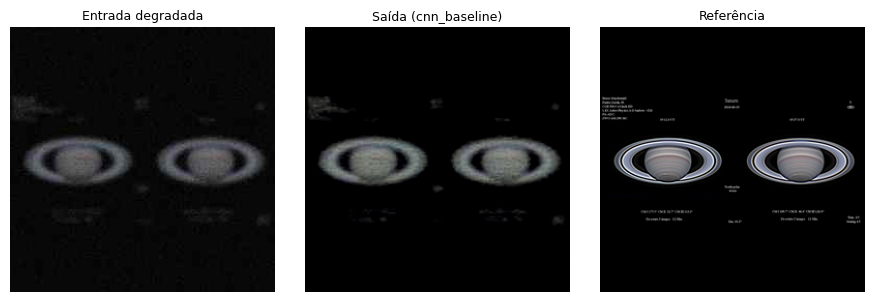

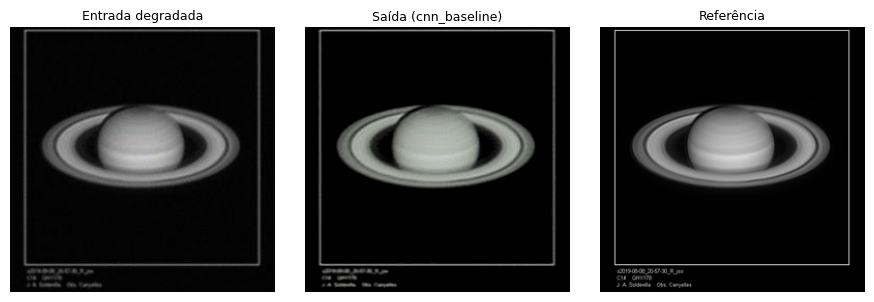

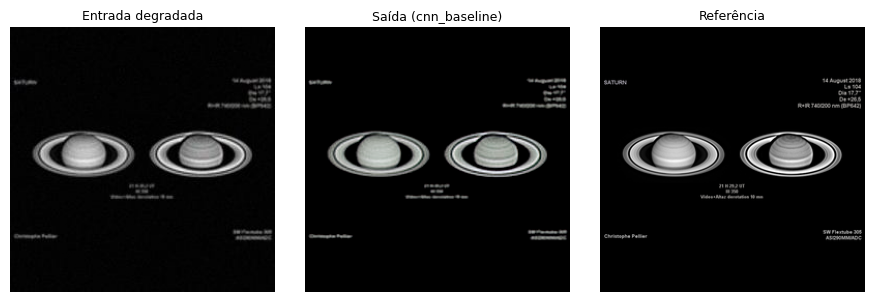

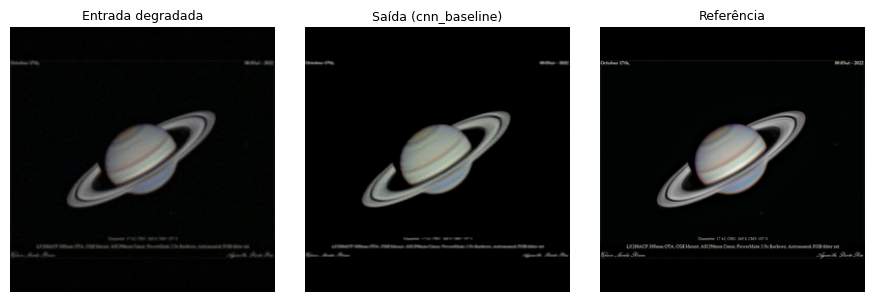

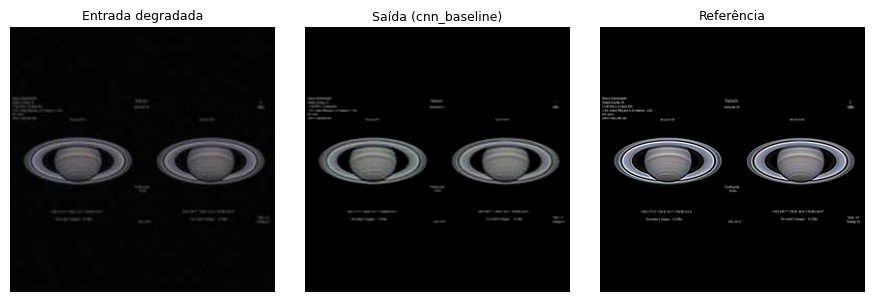

In [11]:
best_model.eval()
n_samples = 5
sample_indices = random.sample(range(len(test_dataset)), min(n_samples, len(test_dataset)))

with torch.no_grad():
    for idx in sample_indices:
        degraded, target = test_dataset[idx]
        output = best_model(degraded.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

        degraded_img = degraded.permute(1, 2, 0).numpy()
        output_img = output.permute(1, 2, 0).numpy()
        target_img = target.permute(1, 2, 0).numpy()

        plt.figure(figsize=(9, 3))
        for pos, (img, title) in enumerate([
            (degraded_img, "Entrada degradada"),
            (output_img, f"Saída ({best_model_name})"),
            (target_img, "Referência"),
        ]):
            plt.subplot(1, 3, pos + 1)
            plt.imshow(np.clip(img, 0, 1))
            plt.title(title, fontsize=9)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

## 9.1 Mapas de explicabilidade

A seção 9 do relatório de auditoria pede artefatos explicativos que vão além de MSE/PSNR/SSIM, porque uma métrica boa não garante que o modelo preservou as estruturas certas. Esta célula gera três desses artefatos para algumas amostras de teste, usando `best_model`: o mapa de diferença absoluta (`|saída - entrada|`), que mostra onde o modelo alterou a imagem; o mapa residual amplificado (`k × (saída - entrada)`, com k fixo), que ajuda a enxergar se a mudança parece remoção de ruído ou adição de textura; e o perfil radial de intensidade, uma média de brilho por distância ao centro da imagem, que indica se a transição entre disco e anéis ficou mais ou menos definida depois do processamento — um salto mais nítido no perfil da saída em relação à entrada é evidência de separação disco-anéis mais legível, enquanto um perfil quase idêntico ao da referência mas com oscilações extras sugere textura inventada.

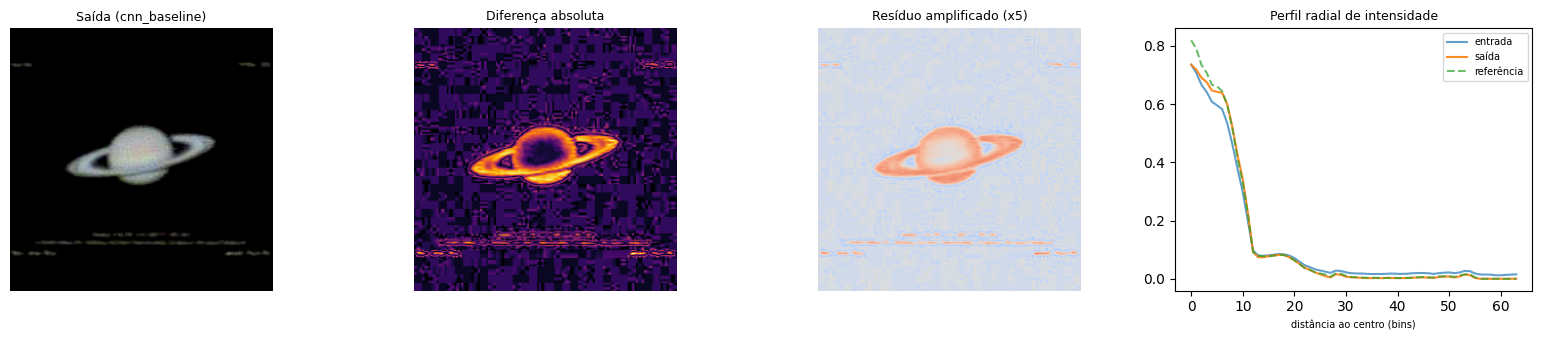

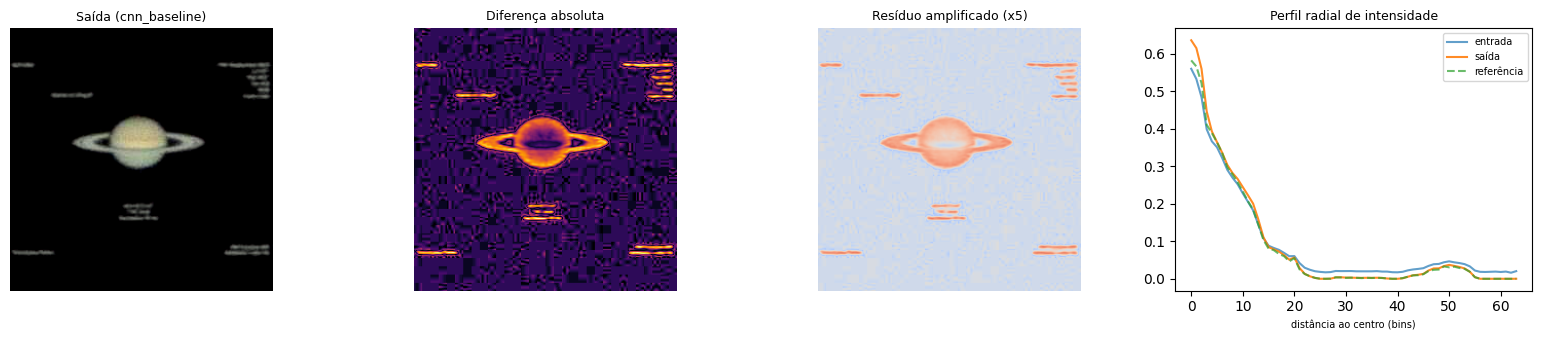

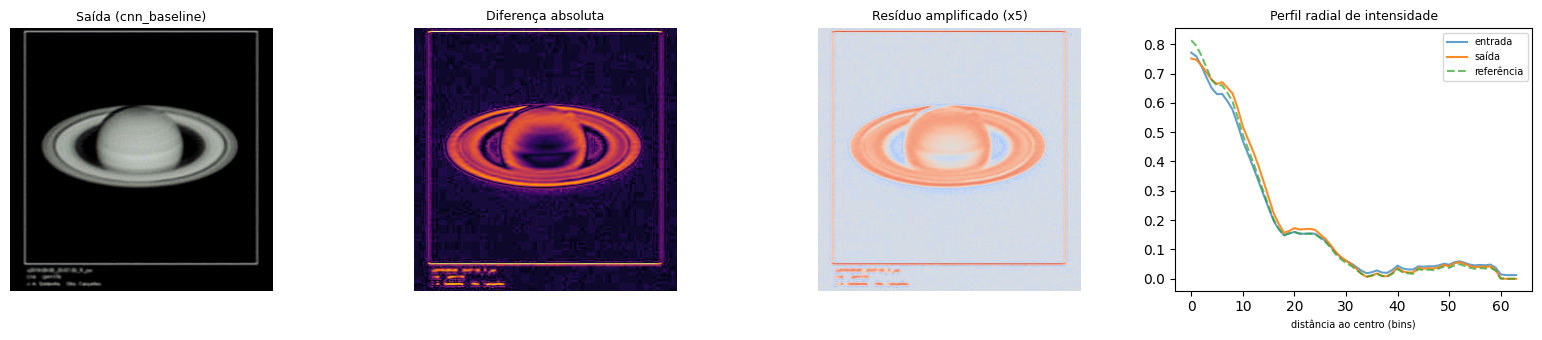

In [12]:
AMPLIFICATION_FACTOR = 5

def radial_intensity_profile(img_array, n_bins=64):
    h, w = img_array.shape[:2]
    gray = img_array.mean(axis=-1) if img_array.ndim == 3 else img_array
    cy, cx = h / 2.0, w / 2.0
    y_idx, x_idx = np.indices((h, w))
    radius = np.sqrt((y_idx - cy) ** 2 + (x_idx - cx) ** 2)
    max_radius = radius.max()

    bins = np.linspace(0, max_radius, n_bins + 1)
    profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (radius >= bins[i]) & (radius < bins[i + 1])
        profile[i] = gray[mask].mean() if mask.any() else np.nan
    return profile

best_model.eval()
n_explain_samples = 3
explain_indices = random.sample(range(len(test_dataset)), min(n_explain_samples, len(test_dataset)))

with torch.no_grad():
    for idx in explain_indices:
        degraded, target = test_dataset[idx]
        output = best_model(degraded.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

        degraded_img = np.clip(degraded.permute(1, 2, 0).numpy(), 0, 1)
        output_img = np.clip(output.permute(1, 2, 0).numpy(), 0, 1)
        target_img = np.clip(target.permute(1, 2, 0).numpy(), 0, 1)

        diff_map = np.abs(output_img - degraded_img).mean(axis=-1)
        residual_map = np.clip(AMPLIFICATION_FACTOR * (output_img - degraded_img), -1, 1).mean(axis=-1)

        profile_input = radial_intensity_profile(degraded_img)
        profile_output = radial_intensity_profile(output_img)
        profile_target = radial_intensity_profile(target_img)

        fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
        axes[0].imshow(output_img)
        axes[0].set_title(f"Saída ({best_model_name})", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(diff_map, cmap="inferno")
        axes[1].set_title("Diferença absoluta", fontsize=9)
        axes[1].axis("off")

        axes[2].imshow(residual_map, cmap="coolwarm", vmin=-1, vmax=1)
        axes[2].set_title(f"Resíduo amplificado (x{AMPLIFICATION_FACTOR})", fontsize=9)
        axes[2].axis("off")

        axes[3].plot(profile_input, label="entrada", alpha=0.7)
        axes[3].plot(profile_output, label="saída", alpha=0.9)
        axes[3].plot(profile_target, label="referência", alpha=0.7, linestyle="--")
        axes[3].set_title("Perfil radial de intensidade", fontsize=9)
        axes[3].set_xlabel("distância ao centro (bins)", fontsize=7)
        axes[3].legend(fontsize=7)

        plt.tight_layout()
        plt.show()

## 10. Super-resolução para 1024px com modelo pré-treinado do Hugging Face

Esta é a etapa que leva as imagens de 256 para 1024 pixels, usando o Swin2SR (`caidas/swin2SR-classical-sr-x4-64`), publicado pela Hugging Face e integrado à biblioteca `transformers` (classe `Swin2SRForImageSuperResolution`), especializado em multiplicar a resolução de uma imagem por 4. Diferente das quatro arquiteturas da seção 5, este modelo não é treinado neste notebook — ele entra pronto, e sua função aqui é puramente de resolução.

https://ar5iv.labs.arxiv.org/html/2209.11345

A função `enhance_and_upscale` encadeia dois modelos: primeiro a imagem normalizada de 256×256 passa por `best_model` (a arquitetura vencedora da seção 8, redução de ruído e realce), depois o resultado passa pelo Swin2SR, que devolve uma reconstrução em 1024×1024. Essa ordem — modelo próprio primeiro, super-resolução depois — evita que o Swin2SR amplifique o ruído junto com o resto da imagem.

In [13]:
from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution

sr_processor = AutoImageProcessor.from_pretrained(SR_MODEL_NAME)
sr_model = Swin2SRForImageSuperResolution.from_pretrained(SR_MODEL_NAME).to(DEVICE)
sr_model.eval()

print(f"Modelo de super-resolução carregado: {SR_MODEL_NAME}")
print(f"Modelo de realce usado antes da super-resolução: {best_model_name}")

def enhance_and_upscale(image_path, target_size=TARGET_UPSCALE_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")

    img_t = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        enhanced_t = best_model(img_t)
    enhanced_np = (enhanced_t.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255.0).round().astype(np.uint8)
    enhanced_img = Image.fromarray(enhanced_np)

    inputs = sr_processor(enhanced_img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = sr_model(**inputs)

    reconstruction = outputs.reconstruction.data.squeeze().float().cpu().clamp_(0, 1).numpy()
    reconstruction = np.moveaxis(reconstruction, 0, -1)
    reconstruction = (reconstruction * 255.0).round().astype(np.uint8)
    upscaled_img = Image.fromarray(reconstruction)

    if upscaled_img.size != (target_size, target_size):
        upscaled_img = upscaled_img.resize((target_size, target_size), Image.Resampling.LANCZOS)

    return enhanced_img, upscaled_img

preprocessor_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/726 [00:00<?, ?it/s]

Modelo de super-resolução carregado: caidas/swin2SR-classical-sr-x4-64
Modelo de realce usado antes da super-resolução: cnn_baseline


## 11. Rodando o pipeline completo sobre o catálogo mestre

Esta célula aplica `enhance_and_upscale` às imagens normalizadas da Fase 1, mas só às que passaram na validação rigorosa da seção 3.1 — qualquer imagem sem disco e anéis claramente visíveis, ou reprovada por baixa confiança/margem, é excluída antes mesmo de entrar na fila de processamento, e não apenas descartada visualmente depois. O resultado (versão realçada em 256 e versão final em 1024) é salvo com um manifesto (`upscaled_manifest.csv`) que registra o caminho de cada arquivo, a resolução final, o modelo de realce e o modelo de super-resolução usados.

Para processar mais do que a amostra padrão, aumente `MAX_IMAGES_TO_UPSCALE` na seção 2 e rode esta célula de novo — ela pula imagens que já têm uma versão em 1024 salva, então retomar de onde parou não repete trabalho já feito.

In [14]:
upscaled_manifest_path = DIRS["metadata"] / "upscaled_manifest.csv"

if upscaled_manifest_path.exists():
    upscaled_manifest_df = pd.read_csv(upscaled_manifest_path)
else:
    upscaled_manifest_df = pd.DataFrame(columns=[
        "image_id", "source_normalized_path", "upscaled_path",
        "width", "height", "enhance_model", "sr_model", "processed_at_utc",
    ])

already_upscaled = set(upscaled_manifest_df["image_id"].astype(str))

normalized_ok = normalized_manifest_df[normalized_manifest_df["status"] == "ok"].copy()
n_before_content_filter = len(normalized_ok)
normalized_ok = normalized_ok[normalized_ok["image_id"].astype(str).isin(approved_image_ids)]
n_removed_content = n_before_content_filter - len(normalized_ok)

to_process = normalized_ok[~normalized_ok["image_id"].astype(str).isin(already_upscaled)].reset_index(drop=True).head(MAX_IMAGES_TO_UPSCALE)

print(f"Imagens normalizadas disponíveis: {n_before_content_filter}")
print(f"Removidas por reprovação na validação rigorosa de conteúdo: {n_removed_content}")
print(f"{len(already_upscaled)} imagem(ns) já processada(s) em execuções anteriores.")
print(f"{len(to_process)} imagem(ns) será(ão) processada(s) nesta execução (limite: {MAX_IMAGES_TO_UPSCALE}).\n")

new_records = []
for _, row in tqdm(to_process.iterrows(), total=len(to_process), desc=f"{best_model_name} + Swin2SR (256 -> 1024)"):
    image_id = row["image_id"]
    try:
        _, upscaled_img = enhance_and_upscale(row["normalized_path"])
        out_path = DIRS["upscaled_1024"] / f"{image_id}_1024.png"
        upscaled_img.save(out_path, "PNG", optimize=True)

        new_records.append({
            "image_id": image_id,
            "source_normalized_path": row["normalized_path"],
            "upscaled_path": str(out_path),
            "width": upscaled_img.width,
            "height": upscaled_img.height,
            "enhance_model": best_model_name,
            "sr_model": SR_MODEL_NAME,
            "processed_at_utc": utc_now_iso(),
        })
    except Exception as exc:
        print(f"Falha ao processar {image_id}: {type(exc).__name__}: {exc}")

if new_records:
    upscaled_manifest_df = pd.concat([upscaled_manifest_df, pd.DataFrame(new_records)], ignore_index=True)
    upscaled_manifest_df.to_csv(upscaled_manifest_path, index=False)

print(f"\nManifesto de imagens em alta resolução salvo em: {upscaled_manifest_path}")
print(f"Total de imagens em 1024x1024 até agora: {len(upscaled_manifest_df)}")

Imagens normalizadas disponíveis: 1000
Removidas por reprovação na validação rigorosa de conteúdo: 878
180 imagem(ns) já processada(s) em execuções anteriores.
40 imagem(ns) será(ão) processada(s) nesta execução (limite: 40).



cnn_baseline + Swin2SR (256 -> 1024):   0%|          | 0/40 [00:00<?, ?it/s]


Manifesto de imagens em alta resolução salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/upscaled_manifest.csv
Total de imagens em 1024x1024 até agora: 220


## 11.1 Mapas de explicabilidade — catálogo final (1024px)

Esta célula estende a análise da seção 9.1 para todas as imagens já processadas em `upscaled_manifest_df` (seção 11), em vez de amostras aleatórias do split de teste sintético. Como são fotos reais sem referência sintética, o mapa de diferença e o resíduo comparam a saída de `best_model` contra a imagem normalizada original (ambas em 256px), e o perfil radial passa a incluir também o resultado final em 1024px, após o Swin2SR. Os resultados quantitativos por imagem (diferença média/máxima e resíduo médio absoluto) vão para `explainability_summary.csv`, e as figuras individuais são salvas em `explainability_1024/` em vez de exibidas inline, já que o volume deixa de ser de 3 amostras para o catálogo inteiro.

In [15]:
best_model.eval()

explain_dir = DIRS["metadata"].parent / "explainability_1024"
explain_dir.mkdir(parents=True, exist_ok=True)

explain_records = []

with torch.no_grad():
    for _, row in tqdm(upscaled_manifest_df.iterrows(),
                        total=len(upscaled_manifest_df),
                        desc="Mapas de explicabilidade (catálogo final)"):
        image_id = row["image_id"]

        original_img = Image.open(row["source_normalized_path"]).convert("RGB")
        original_np = np.asarray(original_img, dtype=np.float32) / 255.0
        original_t = torch.from_numpy(original_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        enhanced_t = best_model(original_t).cpu().squeeze(0)
        enhanced_img = np.clip(enhanced_t.permute(1, 2, 0).numpy(), 0, 1)

        final_img = np.asarray(Image.open(row["upscaled_path"]).convert("RGB"), dtype=np.float32) / 255.0

        diff_map = np.abs(enhanced_img - original_np).mean(axis=-1)
        residual_map = np.clip(AMPLIFICATION_FACTOR * (enhanced_img - original_np), -1, 1).mean(axis=-1)

        profile_input = radial_intensity_profile(original_np)
        profile_enhanced = radial_intensity_profile(enhanced_img)
        profile_final = radial_intensity_profile(final_img)

        explain_records.append({
            "image_id": image_id,
            "diff_mean": float(diff_map.mean()),
            "diff_max": float(diff_map.max()),
            "residual_mean_abs": float(np.abs(residual_map).mean()),
        })

        fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
        axes[0].imshow(enhanced_img)
        axes[0].set_title(f"Saída 256px ({best_model_name})", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(diff_map, cmap="inferno")
        axes[1].set_title("Diferença absoluta", fontsize=9)
        axes[1].axis("off")

        axes[2].imshow(residual_map, cmap="coolwarm", vmin=-1, vmax=1)
        axes[2].set_title(f"Resíduo amplificado (x{AMPLIFICATION_FACTOR})", fontsize=9)
        axes[2].axis("off")

        axes[3].plot(profile_input, label="entrada 256", alpha=0.7)
        axes[3].plot(profile_enhanced, label="saída 256", alpha=0.9)
        axes[3].plot(profile_final, label="final 1024", alpha=0.7, linestyle="--")
        axes[3].set_title("Perfil radial de intensidade", fontsize=9)
        axes[3].set_xlabel("distância ao centro (bins)", fontsize=7)
        axes[3].legend(fontsize=7)

        plt.tight_layout()
        fig.savefig(explain_dir / f"{image_id}_explain.png", dpi=110)
        plt.close(fig)

explain_summary_df = pd.DataFrame(explain_records)
explain_summary_path = DIRS["metadata"] / "explainability_summary.csv"
explain_summary_df.to_csv(explain_summary_path, index=False)

print(f"Mapas de explicabilidade gerados para {len(explain_summary_df)} imagem(ns) do catálogo final.")
print(f"Figuras individuais salvas em: {explain_dir}")
print(f"Resumo quantitativo salvo em: {explain_summary_path}")
print(explain_summary_df.describe()[["diff_mean", "diff_max", "residual_mean_abs"]].to_string())


Mapas de explicabilidade (catálogo final):   0%|          | 0/220 [00:00<?, ?it/s]

Mapas de explicabilidade gerados para 220 imagem(ns) do catálogo final.
Figuras individuais salvas em: /content/drive/MyDrive/dataset_saturno_v1/explainability_1024
Resumo quantitativo salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/explainability_summary.csv
        diff_mean    diff_max  residual_mean_abs
count  220.000000  220.000000         220.000000
mean     0.011727    0.186160           0.058080
std      0.007009    0.047095           0.034899
min      0.001387    0.116629           0.006815
25%      0.006169    0.153035           0.030200
50%      0.009304    0.170187           0.046050
75%      0.016931    0.214581           0.084390
max      0.042007    0.360214           0.209620


## 12. Conferência visual do resultado final em 1024px

Uma última checagem visual, desta vez ponta a ponta: a imagem normalizada original em 256×256 ao lado da versão final em 1024×1024, já passada por `best_model` e pelo Swin2SR. Vale complementar com PSNR/SSIM da seção 8, já que uma imagem pode parecer mais nítida visualmente e ainda assim conter detalhe inventado pelo modelo de super-resolução — e, com a validação rigorosa da seção 3.1 em vigor, toda imagem que chega até aqui já foi confirmada como mostrando disco e anéis, então a inspeção pode se concentrar na qualidade da reconstrução, não mais em checar se o conteúdo é o certo.

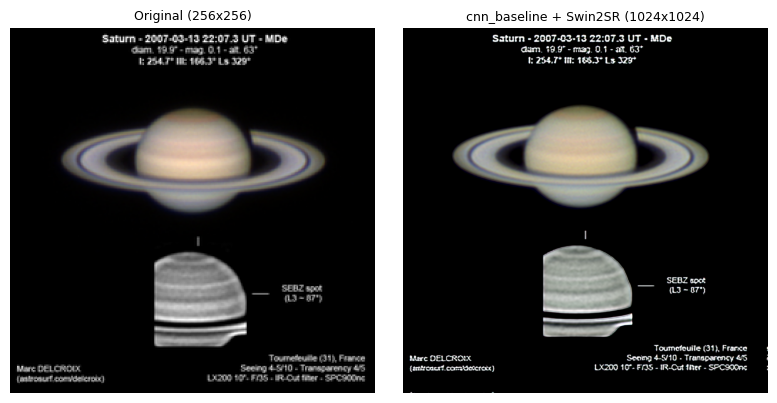

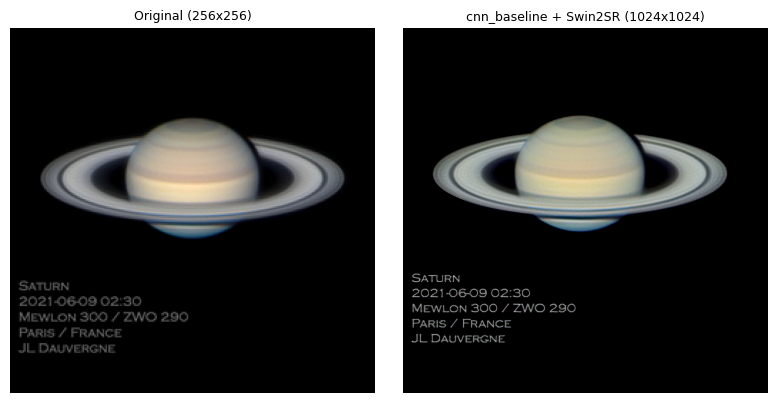

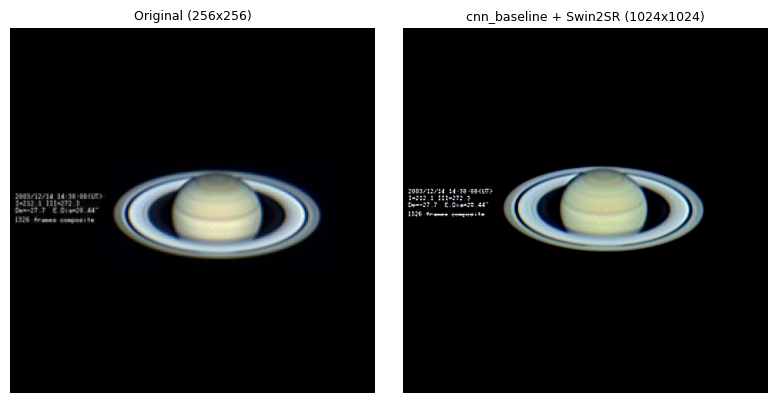

In [16]:
sample_rows = upscaled_manifest_df.sample(min(3, len(upscaled_manifest_df)), random_state=RANDOM_SEED)

for _, row in sample_rows.iterrows():
    original_img = Image.open(row["source_normalized_path"]).convert("RGB")
    final_img = Image.open(row["upscaled_path"]).convert("RGB")

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Original ({original_img.width}x{original_img.height})", fontsize=9)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(final_img)
    plt.title(f"{row.get('enhance_model', best_model_name)} + Swin2SR ({final_img.width}x{final_img.height})", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 13. Model card e resumo da Fase 2

Fechando o notebook, esta célula gera os artefatos de evidência que o relatório de auditoria pede na camada de treinamento (seção 10): `training_run.json`, agora com o histórico e os hiperparâmetros de todas as quatro arquiteturas, não só da vencedora, e `model_card.md`, no formato do Anexo A do relatório, descrevendo a arquitetura escolhida, a comparação entre as quatro, a cobertura da validação rigorosa de conteúdo e a quebra de desempenho por severidade de degradação.

In [17]:
if validation_source == "phase1_manifest_final_reviewed":
    content_validation_method = "Manifesto final reaproveitado da Fase 1, com revisão manual aplicada (approved_for_training_final.csv)"
    total_classified = int(len(phase1_approval_df))
    status_breakdown = phase1_approval_df["final_status"].value_counts().to_dict()
elif validation_source == "phase1_manifest":
    content_validation_method = "Manifesto reaproveitado da Fase 1, sem revisão manual aplicada (approved_for_training.csv)"
    total_classified = int(len(phase1_approval_df))
    status_breakdown = phase1_approval_df["status"].value_counts().to_dict()
else:
    content_validation_method = "Classificação própria da Fase 2 (CLIP zero-shot, fallback)"
    total_classified = int(len(strict_validation_df))
    status_breakdown = strict_validation_df["status"].value_counts().to_dict()

training_run = {
    "dataset_version": DATASET_NAME,
    "random_seed": RANDOM_SEED,
    "content_validation": {
        "method": content_validation_method,
        "validation_source": validation_source,
        "model": CLIP_MODEL_NAME,
        "confidence_threshold": STRICT_CONFIDENCE_THRESHOLD,
        "margin_threshold": STRICT_MARGIN_THRESHOLD,
        "borderline_confidence_threshold": STRICT_BORDERLINE_CONFIDENCE_THRESHOLD,
        "approved_statuses": PHASE1_APPROVED_STATUSES,
        "images_in_master_catalog": int(len(master_df)),
        "images_classified": total_classified,
        "status_breakdown": {str(k): int(v) for k, v in status_breakdown.items()},
        "images_approved_for_training": int(len(approved_image_ids)),
        "synthetic_pairs_before_filter": int(n_pairs_before_filter),
        "synthetic_pairs_after_filter": int(len(pairs_df_filtered)),
    },
    "data_augmentation": {
        "enabled": AUGMENT_TRAIN_PAIRS,
        "horizontal_flip_probability": 0.5 if AUGMENT_TRAIN_PAIRS else None,
        "max_rotation_degrees": AUGMENT_MAX_ROTATION_DEGREES if AUGMENT_TRAIN_PAIRS else None,
        "applied_to_splits": ["train"],
    },
    "training_infrastructure": {
        "amp_enabled": USE_AMP,
        "device": str(DEVICE),
        "resumable_checkpoints": True,
    },
    "loss_function": {
        "description": "L1 + (1-SSIM) + gradiente (Sobel) + cor, pesos conforme seção 8.2 do relatório de auditoria",
        "weights": {
            "l1": LOSS_WEIGHT_L1,
            "ssim": LOSS_WEIGHT_SSIM,
            "gradient": LOSS_WEIGHT_GRADIENT,
            "color": LOSS_WEIGHT_COLOR,
        },
    },
    "shared_hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs_configured": NUM_EPOCHS,
        "learning_rate_initial": LEARNING_RATE,
        "lr_scheduler": {"type": "ReduceLROnPlateau", "factor": LR_SCHEDULER_FACTOR, "patience": LR_SCHEDULER_PATIENCE},
        "grad_clip_max_norm": GRAD_CLIP_MAX_NORM,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    },
    "models": {
        name: {
            "parameters": int(count_params(trained_models[name])),
            "epochs_run": len(training_histories[name]["epoch"]),
            "best_epoch": int(best_checkpoints[name]["epoch"]),
            "best_val_loss": float(best_checkpoints[name]["val_loss"]),
            "learning_rate_final": training_histories[name]["learning_rate"][-1],
            "history": training_histories[name],
        }
        for name in trained_models
    },
    "model_comparison_test_set": comparison_df.to_dict(orient="records"),
    "best_model_by_ssim": best_model_name,
    "best_model_by_lpips": best_by_lpips,
    "evaluation_by_severity": severity_summary.to_dict(orient="records"),
    "super_resolution": {
        "model_name": SR_MODEL_NAME,
        "source": "Hugging Face (modelo pré-treinado, não treinado neste notebook)",
        "scale_factor": 4,
        "input_size": IMAGE_SIZE,
        "output_size": TARGET_UPSCALE_SIZE,
        "images_processed": int(len(upscaled_manifest_df)),
    },
    "generated_at_utc": utc_now_iso(),
}

training_run_path = DIRS["metadata"] / "training_run.json"
training_run_path.write_text(json.dumps(training_run, indent=2, ensure_ascii=False), encoding="utf-8")

comparison_table_md = comparison_df.to_string(index=False)
severity_table_md = severity_summary.to_string(index=False)

lpips_agreement_note = (
    f"O melhor modelo por SSIM ({best_model_name}) também é o melhor por LPIPS."
    if best_by_lpips == best_model_name else
    f"Atenção: o melhor modelo por SSIM ({best_model_name}) difere do melhor por LPIPS ({best_by_lpips})."
)

model_card = f'''# Model Card — Fase 2, comparação de arquiteturas (Projeto IA Saturno)

## Finalidade
Redução de ruído e realce de imagens amadoras de Saturno em 256x256, como
etapa de pré-processamento antes da super-resolução para 1024x1024. Parte
da Fase 2 do desenho experimental descrito no relatório de auditoria
técnica do projeto.

## Validação de conteúdo
{content_validation_method}, com limiares de confiança {STRICT_CONFIDENCE_THRESHOLD}
e margem {STRICT_MARGIN_THRESHOLD} para confirmação direta, e confiança
{STRICT_BORDERLINE_CONFIDENCE_THRESHOLD} para a fila de revisão -- ambos os
status ({", ".join(PHASE1_APPROVED_STATUSES)}) contam como aprovados para
treino. De {len(master_df)} imagens no catálogo, {len(approved_image_ids)}
foram aprovadas; os pares sintéticos usados no treinamento foram de
{n_pairs_before_filter} para {len(pairs_df_filtered)} após esse filtro.
Distribuição de status: {status_breakdown}.

## Dados
Treinado sobre os pares sintéticos degradado/referência gerados na Fase 1,
já filtrados pela validação de conteúdo acima, com aumento de dados
(espelhamento horizontal + rotação de até {AUGMENT_MAX_ROTATION_DEGREES}
graus) aplicado apenas ao split de treino. Split: {len(train_dataset)}
pares de treino, {len(val_dataset)} de validação, {len(test_dataset)} de
teste.

## Arquiteturas comparadas
CNN baseline (3 camadas, aprendizado residual), autoencoder convolucional,
DnCNN (15 camadas, aprendizado de resíduo de ruído) e U-Net pequena
(encoder-decoder com conexões de atalho). Todas treinadas com a mesma
função de perda, os mesmos hiperparâmetros e o mesmo critério de parada
antecipada, para que a comparação reflita a arquitetura, não as condições
de treino.

## Comparação no split de teste
{comparison_table_md}

Arquitetura escolhida para a etapa de super-resolução: {best_model_name}
(melhor SSIM médio). {lpips_agreement_note}

## Desempenho por severidade de degradação ({best_model_name})
{severity_table_md}

## Super-resolução (não treinada neste notebook)
A etapa de aumento de resolução para 1024x1024 usa o modelo pré-treinado
{SR_MODEL_NAME}, publicado no Hugging Face, aplicado após a saída de
{best_model_name}.

## Limites
Métricas calculadas contra referência sintética, não contra observação
astronômica independente. O desempenho varia por severidade de degradação,
como mostrado acima. Mesmo com os limiares recalibrados e o aproveitamento
da fila de revisão, o número de pares efetivamente usados no treino ainda
pode ser pequeno em relação ao catálogo total -- isso deve ser reportado
explicitamente ao comparar arquiteturas de capacidades diferentes, já que
um dataset pequeno favorece modelos com menos parâmetros
independentemente do mérito da arquitetura. A validação de conteúdo
reduz, mas não elimina, o risco de imagens ambíguas passarem pelo filtro.
Qualquer imagem em 1024x1024 gerada por este pipeline deve ser tratada
como imagem processada por IA, não como observação bruta.

## Riscos
Uso da saída como se fosse observação astronômica bruta; publicação sem
marcação de "imagem processada por IA"; generalização não verificada para
condições de captura muito diferentes das representadas nos pares de
treino; reprovações incorretas da validação de conteúdo (falsos negativos)
que excluem imagens válidas sem revisão humana; comparação entre
arquiteturas de capacidades muito diferentes treinadas sobre um dataset
efetivo pequeno.

## Uso permitido
Uso interno de pesquisa e como base para discussão metodológica na
dissertação. Publicação de imagens geradas exige a mesma marcação de
proveniência definida na Fase 1.
'''

model_card_path = DIRS["metadata"] / "model_card.md"
model_card_path.write_text(model_card, encoding="utf-8")

print(f"training_run.json salvo em: {training_run_path}")
print(f"model_card.md salvo em: {model_card_path}")


training_run.json salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/training_run.json
model_card.md salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/model_card.md
